# PFPA Summer Intern — Team 1
## Week 1: Automated Market Data Download

**Goal**: For any given public company ticker, automatically download:
1. **Stock price history** (daily OHLCV + dividends)
2. **Quarterly balance sheet** (debt, liabilities, equity)
3. **Market cap** (price × shares outstanding)
4. **Risk-free rate** (1-year US Treasury)

Then **save everything** to structured CSV / Excel files ready for the KMV model next week.

---
**Data source**: Yahoo Finance via `yfinance` (free, no API key needed)  
**Output folder**: `./data/<TICKER>/`

---
## Step 0 · Install & Import

In [1]:
# Run this cell once to install all dependencies
import subprocess, sys

pkgs = ['yfinance', 'pandas', 'numpy', 'matplotlib', 'openpyxl', 'requests']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed')

✅ All packages installed


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import os
import warnings
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)

plt.rcParams.update({
    'figure.figsize' : (13, 4),
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
    'font.size'      : 11,
})

print('✅ Imports complete')
print(f'   yfinance version : {yf.__version__}')
print(f'   pandas   version : {pd.__version__}')

✅ Imports complete
   yfinance version : 0.2.54
   pandas   version : 2.1.4


---
## Step 1 · Configuration

**Only edit this cell** to change which companies you want to download.

In [3]:
# ══════════════════════════════════════════════════════════════════════
#  EDIT HERE — add or remove tickers as needed
# ══════════════════════════════════════════════════════════════════════

TICKERS = ['MSFT', 'AAPL', 'TSLA']   # any US exchange ticker

HISTORY_PERIOD = '2y'    # how much price history:  1y / 2y / 5y / max

OUTPUT_DIR = './data'    # all files saved under  ./data/<TICKER>/

# ══════════════════════════════════════════════════════════════════════

# Create output directories
for t in TICKERS:
    os.makedirs(f'{OUTPUT_DIR}/{t}', exist_ok=True)

print(f'Companies to download : {TICKERS}')
print(f'Price history window  : {HISTORY_PERIOD}')
print(f'Output directory      : {os.path.abspath(OUTPUT_DIR)}')

Companies to download : ['MSFT', 'AAPL', 'TSLA']
Price history window  : 2y
Output directory      : C:\Users\wujie\Downloads\data


---
## Step 2 · Download Stock Price History

For each company we download:
- **Open / High / Low / Close** prices (daily)
- **Volume**
- **Dividends** (needed for KMV: add back to stock price)
- **Stock Splits** (for reference)

`yfinance` automatically adjusts for stock splits.

### Why dividends matter for KMV?
KMV requires the **total return** on equity, not just price appreciation.  
We add back dividends paid since the last quarterly report to the stock price.

In [4]:
def download_price_history(ticker: str, period: str = '2y') -> pd.DataFrame:
    """
    Download daily OHLCV + dividends + splits for a given ticker.

    Returns a DataFrame with columns:
        Open, High, Low, Close, Volume, Dividends, Stock Splits
    Index: Date (datetime, timezone-naive)
    """
    stock = yf.Ticker(ticker)

    # auto_adjust=True → prices already adjusted for splits
    # actions=True     → include Dividends and Stock Splits columns
    df = stock.history(period=period, auto_adjust=True, actions=True)

    # Remove timezone info for consistency
    df.index = df.index.tz_localize(None)
    df.index.name = 'Date'

    # Round prices to 4 decimal places
    price_cols = ['Open', 'High', 'Low', 'Close']
    df[price_cols] = df[price_cols].round(4)

    return df


# ── Download for all tickers ──────────────────────────────────────────────────
price_data = {}

print('Downloading price histories ...\n')
for t in TICKERS:
    print(f'  [{t}]', end=' ')
    df = download_price_history(t, HISTORY_PERIOD)
    price_data[t] = df

    # Save to CSV
    path = f'{OUTPUT_DIR}/{t}/{t}_price_history.csv'
    df.to_csv(path)

    start = df.index[0].date()
    end   = df.index[-1].date()
    total_divs = df['Dividends'].sum()
    print(f'✅  {len(df)} days  ({start} → {end})  '
          f'| Latest close: ${df["Close"].iloc[-1]:,.2f}  '
          f'| Total dividends: ${total_divs:.4f}')

print('\nAll price histories saved to CSV ✅')


  [MSFT] ✅  501 days  (2024-06-20 → 2026-06-18)  | Latest close: $379.40  | Total dividends: $6.8000
  [AAPL] ✅  501 days  (2024-06-20 → 2026-06-18)  | Latest close: $298.01  | Total dividends: $2.0600
  [TSLA] ✅  501 days  (2024-06-20 → 2026-06-18)  | Latest close: $400.49  | Total dividends: $0.0000

All price histories saved to CSV ✅


### 2.1 · Preview Price Data

In [5]:
# Show last 5 rows for each ticker
for t, df in price_data.items():
    print(f'\n── {t} — last 5 trading days ──────────────────────────────────')
    display(df[['Open','High','Low','Close','Volume','Dividends']].tail(5))


── MSFT — last 5 trading days ──────────────────────────────────


,Open,High,Low,Close,Volume,Dividends
Date,,,,,,
2026-06-12,391.43,391.74,382.27,390.74,34865800,0.00
2026-06-15,396.80,401.75,392.85,399.76,32266400,0.00
2026-06-16,395.79,396.84,390.69,393.83,31506800,0.00
2026-06-17,390.25,390.37,377.32,378.91,41987800,0.00
2026-06-18,377.92,381.37,373.28,379.40,58466440,0.00



── AAPL — last 5 trading days ──────────────────────────────────


,Open,High,Low,Close,Volume,Dividends
Date,,,,,,
2026-06-12,296.03,297.14,289.62,291.13,38742100,0.00
2026-06-15,294.12,297.78,291.70,296.42,45732600,0.00
2026-06-16,295.25,300.48,293.97,299.24,39874400,0.00
2026-06-17,300.85,302.07,294.36,295.95,42745100,0.00
2026-06-18,298.44,300.57,295.62,298.01,76701676,0.00



── TSLA — last 5 trading days ──────────────────────────────────


,Open,High,Low,Close,Volume,Dividends
Date,,,,,,
2026-06-12,399.49,406.68,386.76,406.43,63514500,0.00
2026-06-15,412.37,416.00,407.10,411.15,45620500,0.00
2026-06-16,404.11,412.42,400.54,404.66,40255500,0.00
2026-06-17,401.53,405.94,393.76,396.38,43534300,0.00
2026-06-18,398.08,402.52,384.70,400.49,54706416,0.00


### 2.2 · Plot: Closing Price History

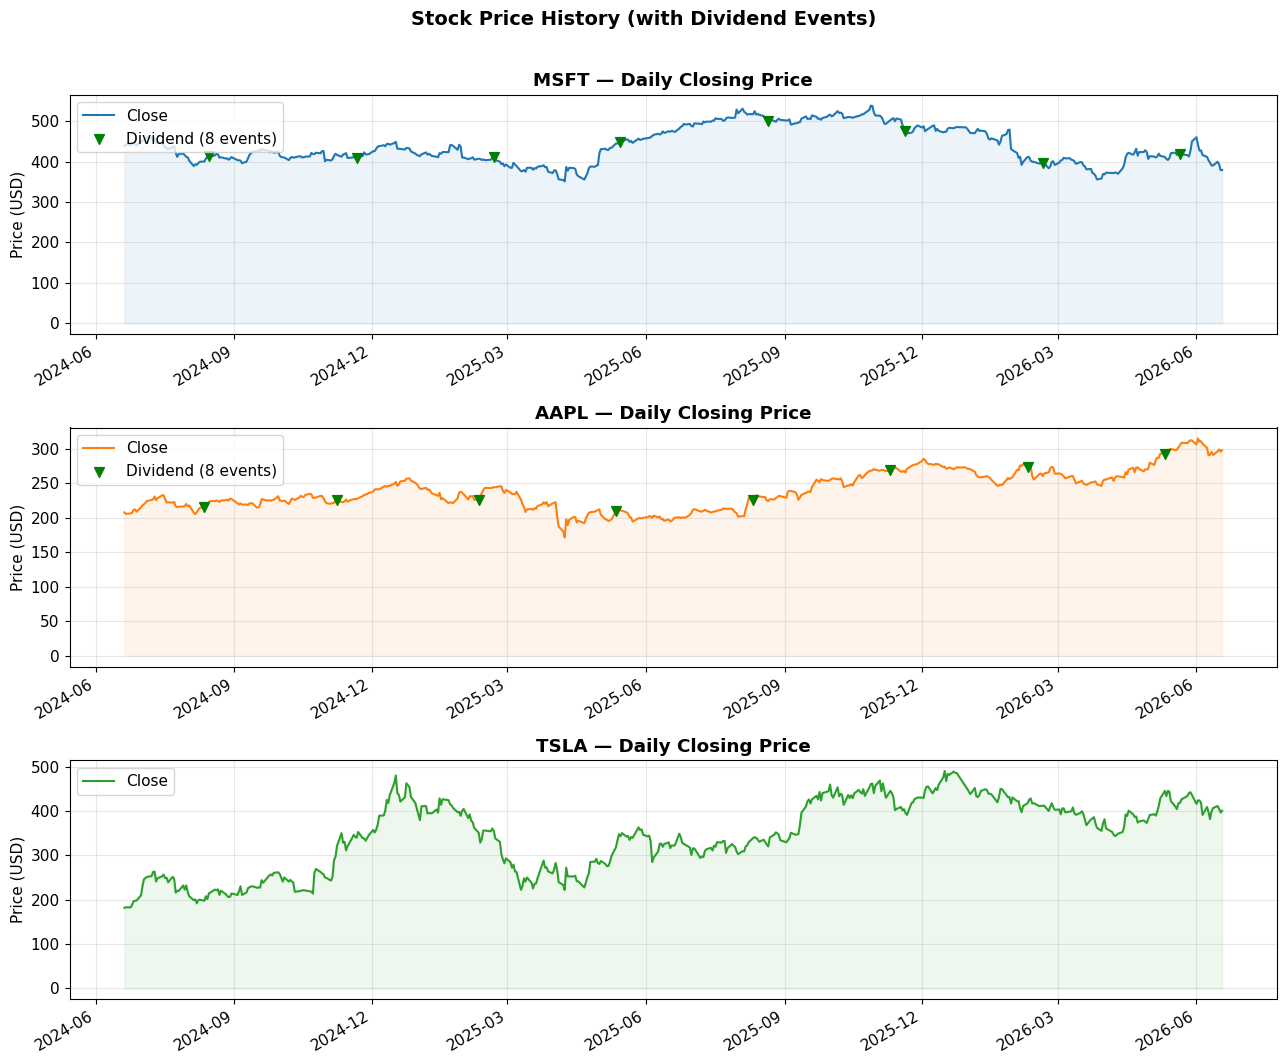

Chart saved ✅


In [6]:
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(len(TICKERS), 1,
                         figsize=(13, 3.5 * len(TICKERS)),
                         sharex=False)
if len(TICKERS) == 1:
    axes = [axes]

for ax, (t, df), color in zip(axes, price_data.items(), COLORS):
    # Price
    ax.plot(df.index, df['Close'], color=color, lw=1.5, label='Close')
    ax.fill_between(df.index, df['Close'], alpha=0.08, color=color)

    # Mark dividend dates
    div_dates = df[df['Dividends'] > 0]
    if not div_dates.empty:
        ax.scatter(div_dates.index, div_dates['Close'],
                   marker='v', color='green', s=50, zorder=5,
                   label=f'Dividend ({len(div_dates)} events)')

    ax.set_title(f'{t} — Daily Closing Price', fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Stock Price History (with Dividend Events)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/price_history_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✅')

### 2.3 · Plot: Comparative Normalised Performance

Normalise all prices to 100 at the start date so we can compare returns on the same scale.

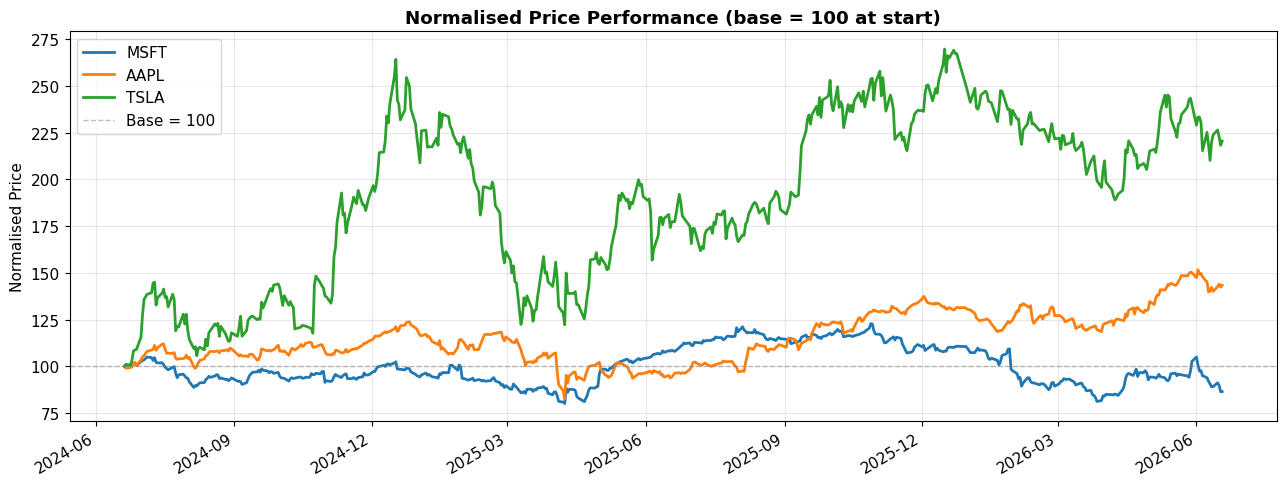

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

for (t, df), color in zip(price_data.items(), COLORS):
    close = df['Close'].dropna()
    normalised = close / close.iloc[0] * 100
    ax.plot(normalised.index, normalised.values, label=t, color=color, lw=2)

ax.axhline(100, color='gray', linestyle='--', lw=1, alpha=0.5, label='Base = 100')
ax.set_title('Normalised Price Performance (base = 100 at start)', fontweight='bold')
ax.set_ylabel('Normalised Price')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/normalised_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 3 · Download Company Info & Shares Outstanding

We need **shares outstanding** to compute market cap:  
$$\text{Market Cap} = \text{Stock Price} \times \text{Shares Outstanding}$$

In [8]:
def download_company_info(ticker: str) -> dict:
    """
    Download static company metadata and shares outstanding.

    Key fields extracted:
        longName, sector, industry, country,
        sharesOutstanding, marketCap, currency,
        trailingPE, forwardPE, dividendYield
    """
    stock = yf.Ticker(ticker)
    raw   = stock.info

    # Fields we care about — with fallback to None
    fields = [
        'longName', 'sector', 'industry', 'country', 'currency',
        'sharesOutstanding', 'impliedSharesOutstanding',
        'marketCap', 'enterpriseValue',
        'trailingPE', 'forwardPE',
        'dividendYield', 'dividendRate',
        'beta', 'fiftyTwoWeekHigh', 'fiftyTwoWeekLow',
        'revenuePerShare', 'bookValue', 'priceToBook',
    ]
    info = {f: raw.get(f, None) for f in fields}

    # Prefer sharesOutstanding; fallback to impliedSharesOutstanding
    info['shares'] = (
        info['sharesOutstanding']
        or info['impliedSharesOutstanding']
        or np.nan
    )

    return info


# ── Download for all tickers ──────────────────────────────────────────────────
company_info = {}

print('Downloading company info ...\n')
for t in TICKERS:
    print(f'  [{t}]', end=' ')
    info = download_company_info(t)
    company_info[t] = info

    # Save to CSV (single-row)
    df_info = pd.DataFrame([info], index=[t])
    df_info.to_csv(f'{OUTPUT_DIR}/{t}/{t}_company_info.csv')

    name   = info.get('longName', t)
    sector = info.get('sector', 'N/A')
    shares = info.get('shares', np.nan)
    print(f'✅  {name}  |  {sector}  |  Shares: {shares:,.0f}')

print('\nCompany info saved ✅')


  [MSFT] ✅  Microsoft Corporation  |  Technology  |  Shares: 7,428,434,704
  [AAPL] ✅  Apple Inc.  |  Technology  |  Shares: 14,687,356,000
  [TSLA] ✅  Tesla, Inc.  |  Consumer Cyclical  |  Shares: 3,755,723,871

Company info saved ✅


In [9]:
# Pretty print the info summary
print('\n' + '='*70)
print('  COMPANY OVERVIEW')
print('='*70)

for t, info in company_info.items():
    shares = info.get('shares', np.nan)
    mc     = info.get('marketCap', np.nan)
    print(f"""
  ── {t} ────────────────────────────────────────────────
  Full Name         : {info.get('longName', 'N/A')}
  Sector            : {info.get('sector', 'N/A')}
  Industry          : {info.get('industry', 'N/A')}
  Country           : {info.get('country', 'N/A')}
  Currency          : {info.get('currency', 'N/A')}
  Shares Outstanding: {shares:>18,.0f}
  Market Cap (Yahoo): ${mc:>17,.0f}
  Beta              : {info.get('beta', 'N/A')}
  52-Week High      : ${info.get('fiftyTwoWeekHigh', 0):>10,.2f}
  52-Week Low       : ${info.get('fiftyTwoWeekLow',  0):>10,.2f}
  Dividend Yield    : {(info.get('dividendYield') or 0):.2%}
""")


  COMPANY OVERVIEW

  ── MSFT ────────────────────────────────────────────────
  Full Name         : Microsoft Corporation
  Sector            : Technology
  Industry          : Software - Infrastructure
  Country           : United States
  Currency          : USD
  Shares Outstanding:      7,428,434,704
  Market Cap (Yahoo): $2,818,348,154,880
  Beta              : 1.103
  52-Week High      : $    555.45
  52-Week Low       : $    356.28
  Dividend Yield    : 92.00%


  ── AAPL ────────────────────────────────────────────────
  Full Name         : Apple Inc.
  Sector            : Technology
  Industry          : Consumer Electronics
  Country           : United States
  Currency          : USD
  Shares Outstanding:     14,687,356,000
  Market Cap (Yahoo): $4,376,979,046,400
  Beta              : 1.086
  52-Week High      : $    317.40
  52-Week Low       : $    196.86
  Dividend Yield    : 36.00%


  ── TSLA ────────────────────────────────────────────────
  Full Name         : Tesl

---
## Step 4 · Compute Daily Market Cap

$$\text{Market Cap}(t) = \text{Close Price}(t) \times \text{Shares Outstanding}$$

Note: Yahoo Finance updates shares outstanding quarterly. We use the single latest figure here,  
which is a standard approximation for this model.

In [10]:
market_cap_data = {}

print('Computing daily market cap ...\n')

for t in TICKERS:
    price_df = price_data[t].copy()
    shares   = company_info[t]['shares']

    if np.isnan(shares):
        print(f'  [{t}] ⚠️  Shares outstanding not available — skipping market cap')
        continue

    # Daily market cap  (raw close × shares)
    mc_df = pd.DataFrame(index=price_df.index)
    mc_df['Close']          = price_df['Close']
    mc_df['Dividends']      = price_df['Dividends']
    mc_df['Shares']         = shares
    mc_df['MarketCap_USD']  = mc_df['Close'] * shares

    # Cumulative dividends per share since start (for reference)
    mc_df['CumDividends']   = mc_df['Dividends'].cumsum()

    # Total return price (close + cumulative dividends)
    mc_df['TotalReturnPrice'] = mc_df['Close'] + mc_df['CumDividends']
    mc_df['MarketCap_TotalReturn'] = mc_df['TotalReturnPrice'] * shares

    market_cap_data[t] = mc_df

    # Save
    mc_df.to_csv(f'{OUTPUT_DIR}/{t}/{t}_market_cap.csv')

    latest_mc = mc_df['MarketCap_USD'].iloc[-1]
    print(f'  [{t}] ✅  Latest Market Cap: ${latest_mc:,.0f}  '
          f'(${latest_mc/1e9:.1f}B)  |  Shares: {shares:,.0f}')

print('\nMarket cap data saved ✅')

Computing daily market cap ...

  [MSFT] ✅  Latest Market Cap: $2,818,348,126,698  ($2818.3B)  |  Shares: 7,428,434,704
  [AAPL] ✅  Latest Market Cap: $4,376,978,961,560  ($4377.0B)  |  Shares: 14,687,356,000
  [TSLA] ✅  Latest Market Cap: $1,504,129,853,097  ($1504.1B)  |  Shares: 3,755,723,871

Market cap data saved ✅


### 4.1 · Plot: Market Cap Over Time

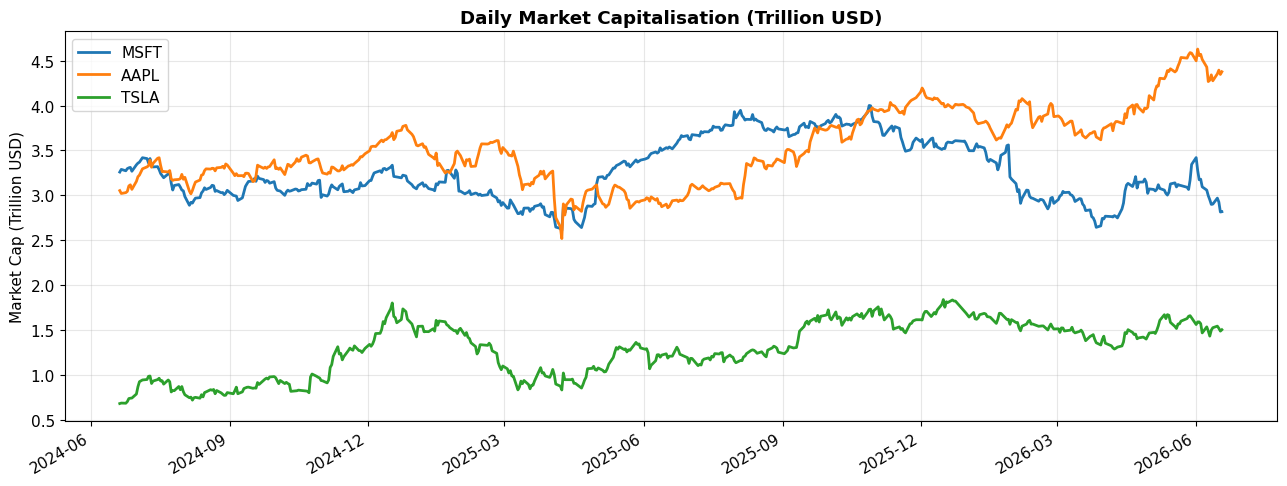

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))

for (t, mc_df), color in zip(market_cap_data.items(), COLORS):
    ax.plot(mc_df.index,
            mc_df['MarketCap_USD'] / 1e12,
            label=t, color=color, lw=2)

ax.set_title('Daily Market Capitalisation (Trillion USD)', fontweight='bold')
ax.set_ylabel('Market Cap (Trillion USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/market_cap_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5 · Download Quarterly Balance Sheet

For the KMV model we need from the balance sheet:

| Field | KMV Role |
|-------|----------|
| Short-term debt (current liabilities from debt) | Core input to $D$ |
| Long-term debt | Core input to $D$ |
| **KMV Debt** $D = \text{ST} + 0.5 \times \text{LT}$ | Barrier in Merton model |
| Total liabilities | Reference |
| Total equity (book) | Reference |
| Total assets (book) | Reference |

In [12]:
# Candidate field names that yfinance may use across different versions
# (field names vary slightly by company/region — we try all candidates)

ST_DEBT_CANDIDATES = [
    'Current Debt And Capital Lease Obligation',
    'Current Debt',
    'Short Long Term Debt',
    'Short Term Debt',
    'CurrentDebt',
]

LT_DEBT_CANDIDATES = [
    'Long Term Debt And Capital Lease Obligation',
    'Long Term Debt',
    'LongTermDebt',
]

OTHER_FIELDS = {
    'TotalLiabilities' : [
        'Total Liabilities Net Minority Interest',
        'Total Liabilities',
        'TotalLiabilitiesNetMinorityInterest',
    ],
    'TotalAssets' : [
        'Total Assets',
        'TotalAssets',
    ],
    'TotalEquity' : [
        'Stockholders Equity',
        'Total Stockholders Equity',
        'StockholdersEquity',
        'Common Stock Equity',
    ],
    'CashAndEquivalents' : [
        'Cash And Cash Equivalents',
        'Cash Cash Equivalents And Short Term Investments',
        'CashAndCashEquivalents',
    ],
}


def first_valid(candidates: list, series: pd.Series) -> float:
    """Return the first non-null value from a list of candidate field names."""
    for c in candidates:
        if c in series.index and pd.notna(series[c]):
            return float(series[c])
    return np.nan


def download_balance_sheet(ticker: str) -> pd.DataFrame:
    """
    Download quarterly balance sheet and extract the fields needed for KMV.

    Returns a DataFrame (one row per quarter) with columns:
        Quarter, ShortTermDebt, LongTermDebt, KMV_Debt_D,
        TotalLiabilities, TotalAssets, TotalEquity,
        CashAndEquivalents, Leverage_D_over_Assets
    """
    stock = yf.Ticker(ticker)
    bs    = stock.quarterly_balance_sheet   # columns = quarter dates, rows = fields

    records = []
    for col in bs.columns:                 # col is a Timestamp
        row = bs[col]

        st  = first_valid(ST_DEBT_CANDIDATES, row)
        lt  = first_valid(LT_DEBT_CANDIDATES, row)

        # KMV formula:  D = ST + 0.5 × LT
        st_safe = st if not np.isnan(st) else 0.0
        lt_safe = lt if not np.isnan(lt) else 0.0
        D = st_safe + 0.5 * lt_safe

        rec = {
            'Quarter'          : pd.Timestamp(col).tz_localize(None),
            'ShortTermDebt'    : st,
            'LongTermDebt'     : lt,
            'KMV_Debt_D'       : D,
        }

        for field_name, candidates in OTHER_FIELDS.items():
            rec[field_name] = first_valid(candidates, row)

        # Leverage ratio
        total_assets = rec.get('TotalAssets', np.nan)
        rec['Leverage_D_over_Assets'] = (
            D / total_assets if (total_assets and total_assets > 0) else np.nan
        )

        records.append(rec)

    df = (pd.DataFrame(records)
            .sort_values('Quarter')
            .reset_index(drop=True))

    return df


print('Balance sheet download function defined ✅')

Balance sheet download function defined ✅


In [13]:
balance_sheet_data = {}

print('Downloading quarterly balance sheets ...\n')

for t in TICKERS:
    print(f'  [{t}]', end=' ')
    df_bs = download_balance_sheet(t)
    balance_sheet_data[t] = df_bs

    # Save to CSV
    df_bs.to_csv(f'{OUTPUT_DIR}/{t}/{t}_balance_sheet.csv', index=False)

    n_quarters = len(df_bs)
    latest = df_bs.iloc[-1]
    print(f'✅  {n_quarters} quarters  '
          f'| Latest ({latest["Quarter"].date()})  '
          f'ST Debt: ${latest["ShortTermDebt"]:>12,.0f}  '
          f'LT Debt: ${latest["LongTermDebt"]:>12,.0f}  '
          f'D: ${latest["KMV_Debt_D"]:>12,.0f}')

print('\nBalance sheets saved ✅')


  [MSFT] ✅  7 quarters  | Latest (2026-03-31)  ST Debt: $8,839,000,000  LT Debt: $48,126,000,000  D: $32,902,000,000
  [AAPL] ✅  7 quarters  | Latest (2026-03-31)  ST Debt: $10,307,000,000  LT Debt: $74,404,000,000  D: $47,509,000,000
  [TSLA] ✅  7 quarters  | Latest (2026-03-31)  ST Debt: $2,435,000,000  LT Debt: $13,455,000,000  D: $9,162,500,000

Balance sheets saved ✅


### 5.1 · Preview Balance Sheet

In [14]:
for t, df_bs in balance_sheet_data.items():
    print(f'\n── {t} — Quarterly Balance Sheet ──────────────────────────────────')
    show_cols = ['Quarter', 'ShortTermDebt', 'LongTermDebt', 'KMV_Debt_D',
                 'TotalAssets', 'TotalEquity', 'Leverage_D_over_Assets']
    display(df_bs[show_cols].tail(8).to_string(index=False))
    print()


── MSFT — Quarterly Balance Sheet ──────────────────────────────────


'   Quarter    ShortTermDebt      LongTermDebt        KMV_Debt_D        TotalAssets        TotalEquity  Leverage_D_over_Assets\n2024-09-30              NaN               NaN              0.00                NaN                NaN                     NaN\n2024-12-31              NaN               NaN              0.00                NaN                NaN                     NaN\n2025-03-31 2,999,000,000.00 57,568,000,000.00 31,783,000,000.00 562,624,000,000.00 321,891,000,000.00                    0.06\n2025-06-30 2,999,000,000.00 57,589,000,000.00 31,793,500,000.00 619,003,000,000.00 343,479,000,000.00                    0.05\n2025-09-30 7,832,000,000.00 52,724,000,000.00 34,194,000,000.00 636,351,000,000.00 363,076,000,000.00                    0.05\n2025-12-31 4,837,000,000.00 52,770,000,000.00 31,222,000,000.00 665,302,000,000.00 390,875,000,000.00                    0.05\n2026-03-31 8,839,000,000.00 48,126,000,000.00 32,902,000,000.00 694,228,000,000.00 414,367,000,000.00         



── AAPL — Quarterly Balance Sheet ──────────────────────────────────


'   Quarter     ShortTermDebt      LongTermDebt        KMV_Debt_D        TotalAssets        TotalEquity  Leverage_D_over_Assets\n2024-09-30               NaN               NaN              0.00                NaN                NaN                     NaN\n2024-12-31               NaN               NaN              0.00                NaN                NaN                     NaN\n2025-03-31 19,620,000,000.00 78,566,000,000.00 58,903,000,000.00 331,233,000,000.00  66,796,000,000.00                    0.18\n2025-06-30 19,268,000,000.00 82,430,000,000.00 60,483,000,000.00 331,495,000,000.00  65,830,000,000.00                    0.18\n2025-09-30 20,329,000,000.00 78,328,000,000.00 59,493,000,000.00 359,241,000,000.00  73,733,000,000.00                    0.17\n2025-12-31 13,824,000,000.00 76,685,000,000.00 52,166,500,000.00 379,297,000,000.00  88,190,000,000.00                    0.14\n2026-03-31 10,307,000,000.00 74,404,000,000.00 47,509,000,000.00 371,082,000,000.00 106,491,000,000.00 



── TSLA — Quarterly Balance Sheet ──────────────────────────────────


'   Quarter    ShortTermDebt      LongTermDebt       KMV_Debt_D        TotalAssets       TotalEquity  Leverage_D_over_Assets\n2024-09-30              NaN               NaN             0.00                NaN               NaN                     NaN\n2024-12-31              NaN               NaN             0.00                NaN               NaN                     NaN\n2025-03-31 3,079,000,000.00 10,049,000,000.00 8,103,500,000.00 125,111,000,000.00 74,653,000,000.00                    0.06\n2025-06-30 2,932,000,000.00 10,202,000,000.00 8,033,000,000.00 128,567,000,000.00 77,314,000,000.00                    0.06\n2025-09-30 2,845,000,000.00 10,943,000,000.00 8,316,500,000.00 133,735,000,000.00 79,970,000,000.00                    0.06\n2025-12-31 2,594,000,000.00 12,125,000,000.00 8,656,500,000.00 137,806,000,000.00 82,137,000,000.00                    0.06\n2026-03-31 2,435,000,000.00 13,455,000,000.00 9,162,500,000.00 143,724,000,000.00 84,116,000,000.00                    0.06'

### 5.2 · Plot: Debt Structure Over Time

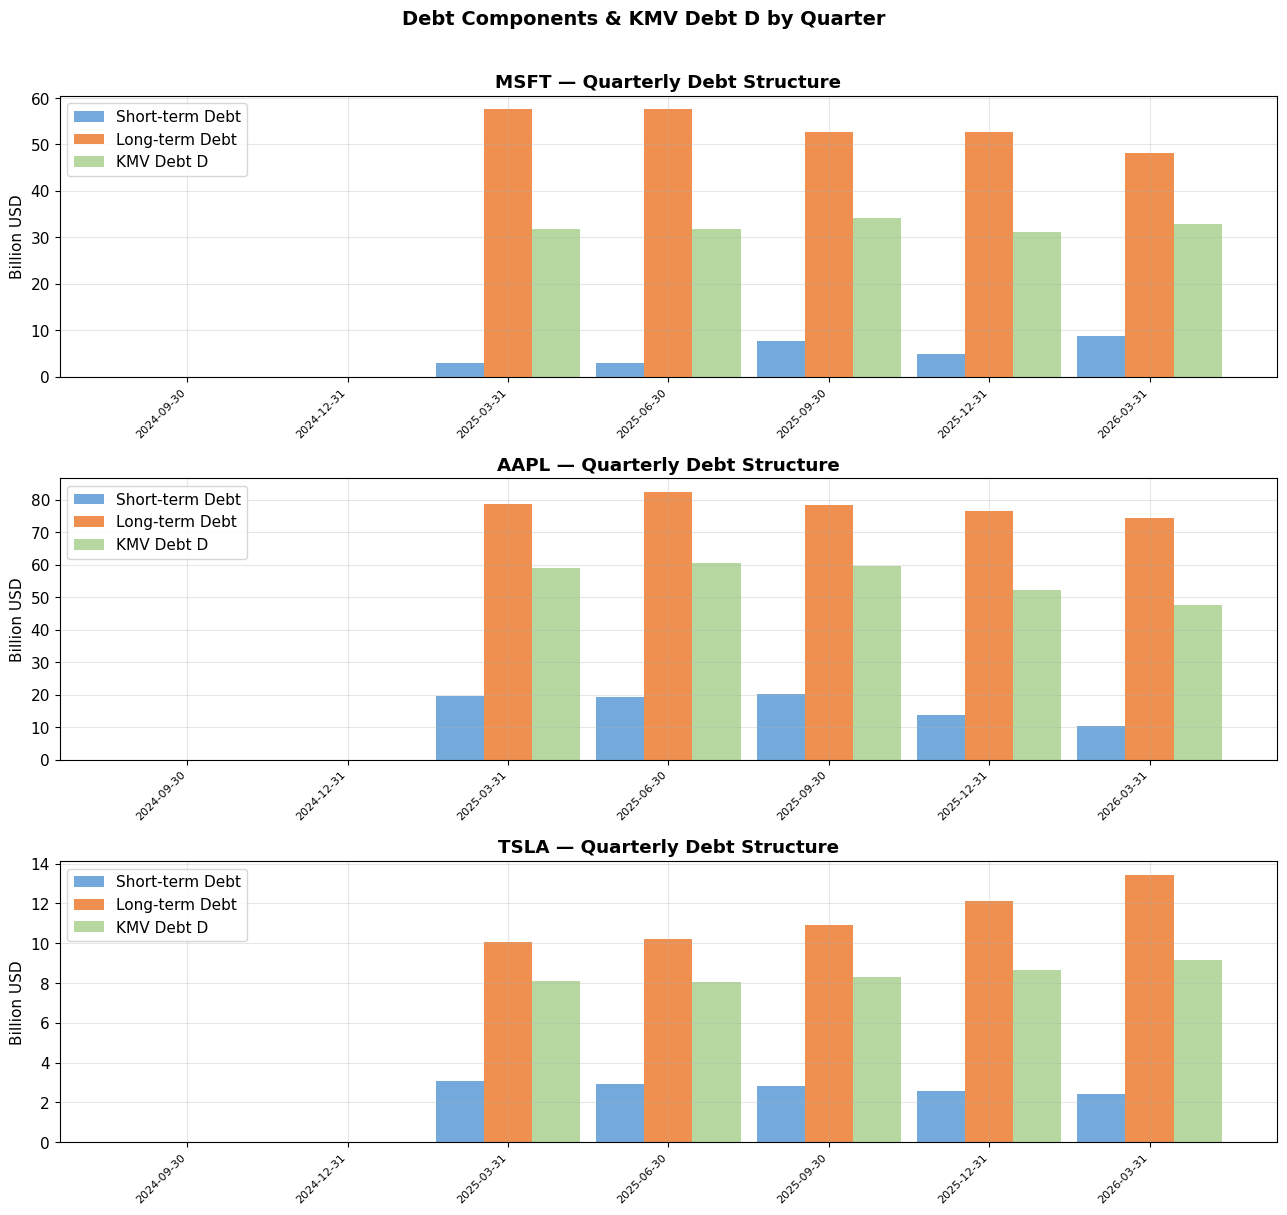

In [15]:
fig, axes = plt.subplots(len(TICKERS), 1,
                         figsize=(13, 4 * len(TICKERS)),
                         sharex=False)
if len(TICKERS) == 1:
    axes = [axes]

for ax, (t, df_bs), color in zip(axes, balance_sheet_data.items(), COLORS):
    # Convert to billions
    q   = df_bs['Quarter']
    st  = df_bs['ShortTermDebt'].fillna(0) / 1e9
    lt  = df_bs['LongTermDebt'].fillna(0)  / 1e9
    D   = df_bs['KMV_Debt_D'].fillna(0)    / 1e9

    x = range(len(q))
    w = 0.3

    ax.bar([i - w for i in x], st, width=w, label='Short-term Debt', color='#5B9BD5', alpha=0.85)
    ax.bar(x,                  lt, width=w, label='Long-term Debt',  color='#ED7D31', alpha=0.85)
    ax.bar([i + w for i in x], D,  width=w, label='KMV Debt D',      color='#A9D18E', alpha=0.85)

    ax.set_xticks(list(x))
    ax.set_xticklabels([str(d.date()) for d in q], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{t} — Quarterly Debt Structure', fontweight='bold')
    ax.set_ylabel('Billion USD')
    ax.legend(loc='upper left')

plt.suptitle('Debt Components & KMV Debt D by Quarter',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/debt_structure_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6 · Download Risk-Free Rate (1-Year US Treasury)

We use the **1-Year US Treasury yield** as the risk-free rate for the KMV model.  
Ticker: `^IRX` (13-week) or `^TNX` (10-year). For KMV we want the 1-year rate = **`^FVX`** proxy.

In practice, the PFPA slides use ~4.5% (2024 level). We download the historical series so the model
can use the rate contemporaneous with each quarterly balance sheet date.

In [16]:
def download_risk_free_rate(period: str = '2y') -> pd.DataFrame:
    """
    Download the 1-year US Treasury yield from Yahoo Finance.
    Ticker ^IRX = 13-week T-bill (annualised).  Divided by 100 to get decimal.
    We also fetch the 10-year (^TNX) for reference.
    """
    rates = {}
    tickers_rf = {
        'TB_13W' : '^IRX',   # 13-week T-bill  (closest to 1-year proxy)
        'TNX_10Y': '^TNX',   # 10-year T-note  (reference)
    }

    for name, yf_ticker in tickers_rf.items():
        df = yf.Ticker(yf_ticker).history(period=period, auto_adjust=True)
        df.index = df.index.tz_localize(None)
        rates[name] = df['Close'] / 100   # convert from % to decimal

    rf_df = pd.DataFrame(rates)
    rf_df.index.name = 'Date'

    # Forward-fill weekends / holidays
    rf_df = rf_df.ffill()

    return rf_df


print('Downloading US Treasury yield data ...', end=' ')
rf_df = download_risk_free_rate(HISTORY_PERIOD)
rf_df.to_csv(f'{OUTPUT_DIR}/risk_free_rates.csv')

latest_rf = rf_df['TB_13W'].iloc[-1]
print(f'✅  {len(rf_df)} days  |  Latest 13-W T-bill rate: {latest_rf:.4%}')

print(f'\n── Last 5 rows of risk-free rate data ──')
display(rf_df.tail(5))


── Last 5 rows of risk-free rate data ──


,TB_13W,TNX_10Y
Date,,
2026-06-09,0.04,0.05
2026-06-10,0.04,0.05
2026-06-11,0.04,0.04
2026-06-12,0.04,0.04
2026-06-18,0.04,0.04


### 6.1 · Plot: Risk-Free Rate History

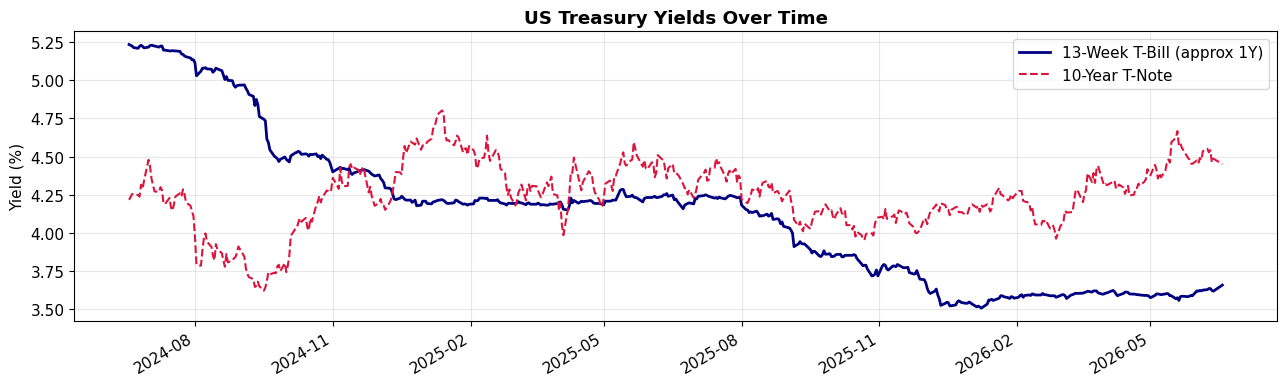

In [17]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(rf_df.index, rf_df['TB_13W']  * 100, label='13-Week T-Bill (approx 1Y)', color='navy',   lw=2)
ax.plot(rf_df.index, rf_df['TNX_10Y'] * 100, label='10-Year T-Note',              color='crimson', lw=1.5, linestyle='--')

ax.set_title('US Treasury Yields Over Time', fontweight='bold')
ax.set_ylabel('Yield (%)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/risk_free_rate_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7 · Merge Everything: Master Dataset

For each company, produce a **single daily table** that the KMV model will consume next week:

| Column | Source | KMV Use |
|--------|--------|---------|
| `Date` | price history | index |
| `Close` | price history | equity per share |
| `Dividends` | price history | total return adjustment |
| `Equity` | close × shares | $E_t$ |
| `ShortTermDebt` | balance sheet (quarterly) | $D_{ST}$ |
| `LongTermDebt` | balance sheet (quarterly) | $D_{LT}$ |
| `KMV_Debt_D` | ST + 0.5×LT | $D$ (barrier) |
| `RiskFreeRate` | Treasury yield | $r$ |
| `Q_Date` | balance sheet | most recent quarter date |

In [18]:
def build_master_dataset(ticker: str,
                         price_df  : pd.DataFrame,
                         mc_df     : pd.DataFrame,
                         bs_df     : pd.DataFrame,
                         rf_df     : pd.DataFrame,
                         shares    : float) -> pd.DataFrame:
    """
    Merge price, market cap, balance sheet, and risk-free rate
    into one daily master DataFrame.

    Balance sheet data is forward-filled from the quarter reporting date
    to the next quarter (i.e., each trading day uses the most recent
    quarterly filing available at that point in time).
    """
    # ── Start with price data ────────────────────────────────────
    master = price_df[['Open', 'High', 'Low', 'Close',
                        'Volume', 'Dividends']].copy()

    # ── Equity = adjusted close × shares ────────────────────────
    # Cumulative dividend add-back resets at each quarter
    # (handled below quarter-by-quarter)
    master['Shares']          = shares
    master['MarketCap_USD']   = master['Close'] * shares
    master['CumDiv_perShare'] = master['Dividends'].cumsum()
    master['AdjClose']        = master['Close'] + master['CumDiv_perShare']
    master['Equity']          = master['AdjClose'] * shares

    # ── Map quarterly balance sheet onto trading days ────────────
    # For each trading day, find the most recent quarter ≤ that day
    bs_df_sorted = bs_df.sort_values('Quarter')

    q_cols = ['Quarter', 'ShortTermDebt', 'LongTermDebt',
               'KMV_Debt_D', 'TotalAssets', 'TotalLiabilities',
               'TotalEquity', 'CashAndEquivalents']
    # Only keep available columns
    q_cols = [c for c in q_cols if c in bs_df_sorted.columns]

    q_filled = []
    for date in master.index:
        avail = bs_df_sorted[bs_df_sorted['Quarter'] <= date]
        if avail.empty:
            row = {c: np.nan for c in q_cols if c != 'Quarter'}
            row['Q_Date'] = pd.NaT
        else:
            latest_q = avail.iloc[-1]
            row = {c: latest_q[c] for c in q_cols if c != 'Quarter'}
            row['Q_Date'] = latest_q['Quarter']
        q_filled.append(row)

    q_df = pd.DataFrame(q_filled, index=master.index)

    # ── Attach balance sheet columns ─────────────────────────────
    for col in q_df.columns:
        master[col] = q_df[col]

    # ── Attach risk-free rate (merge on date, ffill gaps) ────────
    rf_series = rf_df['TB_13W'].reindex(master.index, method='ffill')
    master['RiskFreeRate'] = rf_series

    # ── Days since last quarterly report (for tau in EM) ─────────
    master['DaysSinceQ'] = (master.index - master['Q_Date']).dt.days.clip(lower=0)

    # tau = 1 - (days since Q) / 250  (fraction of year remaining)
    master['tau'] = (1.0 - master['DaysSinceQ'] / 250.0).clip(lower=1e-4)

    # ── Sanity: E/D ratio (quick leverage check) ─────────────────
    master['E_over_D'] = np.where(
        master['KMV_Debt_D'] > 0,
        master['Equity'] / master['KMV_Debt_D'],
        np.nan
    )

    return master


# ── Build master datasets ─────────────────────────────────────────────────────
master_data = {}

print('Building master datasets ...\n')
for t in TICKERS:
    if t not in market_cap_data or t not in balance_sheet_data:
        print(f'  [{t}] ⚠️  Skipping — missing market cap or balance sheet')
        continue

    shares = company_info[t]['shares']
    master = build_master_dataset(
        ticker    = t,
        price_df  = price_data[t],
        mc_df     = market_cap_data[t],
        bs_df     = balance_sheet_data[t],
        rf_df     = rf_df,
        shares    = shares,
    )
    master_data[t] = master

    # Save to CSV
    master.to_csv(f'{OUTPUT_DIR}/{t}/{t}_master.csv')

    valid_rows = master['KMV_Debt_D'].notna().sum()
    print(f'  [{t}] ✅  {len(master)} rows total  '
          f'| {valid_rows} rows with debt data  '
          f'| Latest E/D ratio: {master["E_over_D"].iloc[-1]:.3f}')

print('\nMaster datasets saved ✅')

Building master datasets ...

  [MSFT] ✅  501 rows total  | 431 rows with debt data  | Latest E/D ratio: 87.194
  [AAPL] ✅  501 rows total  | 431 rows with debt data  | Latest E/D ratio: 92.766
  [TSLA] ✅  501 rows total  | 431 rows with debt data  | Latest E/D ratio: 164.162

Master datasets saved ✅


### 7.1 · Preview Master Dataset

In [19]:
key_cols = ['Close', 'AdjClose', 'Equity', 'KMV_Debt_D',
            'RiskFreeRate', 'tau', 'E_over_D', 'Q_Date']

for t, master in master_data.items():
    print(f'\n── {t} — Master Dataset (last 6 rows) ──────────────────────')
    avail = [c for c in key_cols if c in master.columns]
    display(master[avail].tail(6))


── MSFT — Master Dataset (last 6 rows) ──────────────────────


,Close,AdjClose,Equity,KMV_Debt_D,RiskFreeRate,tau,E_over_D,Q_Date
Date,,,,,,,,
2026-06-11,390.34,397.14,"2,950,128,558,346.56","32,902,000,000.00",0.04,0.71,89.66,2026-03-31
2026-06-12,390.74,397.54,"2,953,099,932,228.16","32,902,000,000.00",0.04,0.71,89.75,2026-03-31
2026-06-15,399.76,406.56,"3,020,104,413,258.24","32,902,000,000.00",0.04,0.70,91.79,2026-03-31
2026-06-16,393.83,400.63,"2,976,053,795,463.52","32,902,000,000.00",0.04,0.69,90.45,2026-03-31
2026-06-17,378.91,385.71,"2,865,221,549,679.84","32,902,000,000.00",0.04,0.69,87.08,2026-03-31
2026-06-18,379.40,386.20,"2,868,861,482,684.80","32,902,000,000.00",0.04,0.68,87.19,2026-03-31



── AAPL — Master Dataset (last 6 rows) ──────────────────────


,Close,AdjClose,Equity,KMV_Debt_D,RiskFreeRate,tau,E_over_D,Q_Date
Date,,,,,,,,
2026-06-11,295.63,297.69,"4,372,279,007,640.00","47,509,000,000.00",0.04,0.71,92.03,2026-03-31
2026-06-12,291.13,293.19,"4,306,185,905,640.00","47,509,000,000.00",0.04,0.71,90.64,2026-03-31
2026-06-15,296.42,298.48,"4,383,882,018,880.00","47,509,000,000.00",0.04,0.70,92.27,2026-03-31
2026-06-16,299.24,301.30,"4,425,300,362,800.00","47,509,000,000.00",0.04,0.69,93.15,2026-03-31
2026-06-17,295.95,298.01,"4,376,978,961,560.00","47,509,000,000.00",0.04,0.69,92.13,2026-03-31
2026-06-18,298.01,300.07,"4,407,234,914,920.00","47,509,000,000.00",0.04,0.68,92.77,2026-03-31



── TSLA — Master Dataset (last 6 rows) ──────────────────────


,Close,AdjClose,Equity,KMV_Debt_D,RiskFreeRate,tau,E_over_D,Q_Date
Date,,,,,,,,
2026-06-11,399.15,399.15,"1,499,097,183,109.65","9,162,500,000.00",0.04,0.71,163.61,2026-03-31
2026-06-12,406.43,406.43,"1,526,438,852,890.53","9,162,500,000.00",0.04,0.71,166.60,2026-03-31
2026-06-15,411.15,411.15,"1,544,165,869,561.65","9,162,500,000.00",0.04,0.70,168.53,2026-03-31
2026-06-16,404.66,404.66,"1,519,791,221,638.86","9,162,500,000.00",0.04,0.69,165.87,2026-03-31
2026-06-17,396.38,396.38,"1,488,693,827,986.98","9,162,500,000.00",0.04,0.69,162.48,2026-03-31
2026-06-18,400.49,400.49,"1,504,129,853,096.79","9,162,500,000.00",0.04,0.68,164.16,2026-03-31


### 7.2 · Plot: Equity vs KMV Debt D

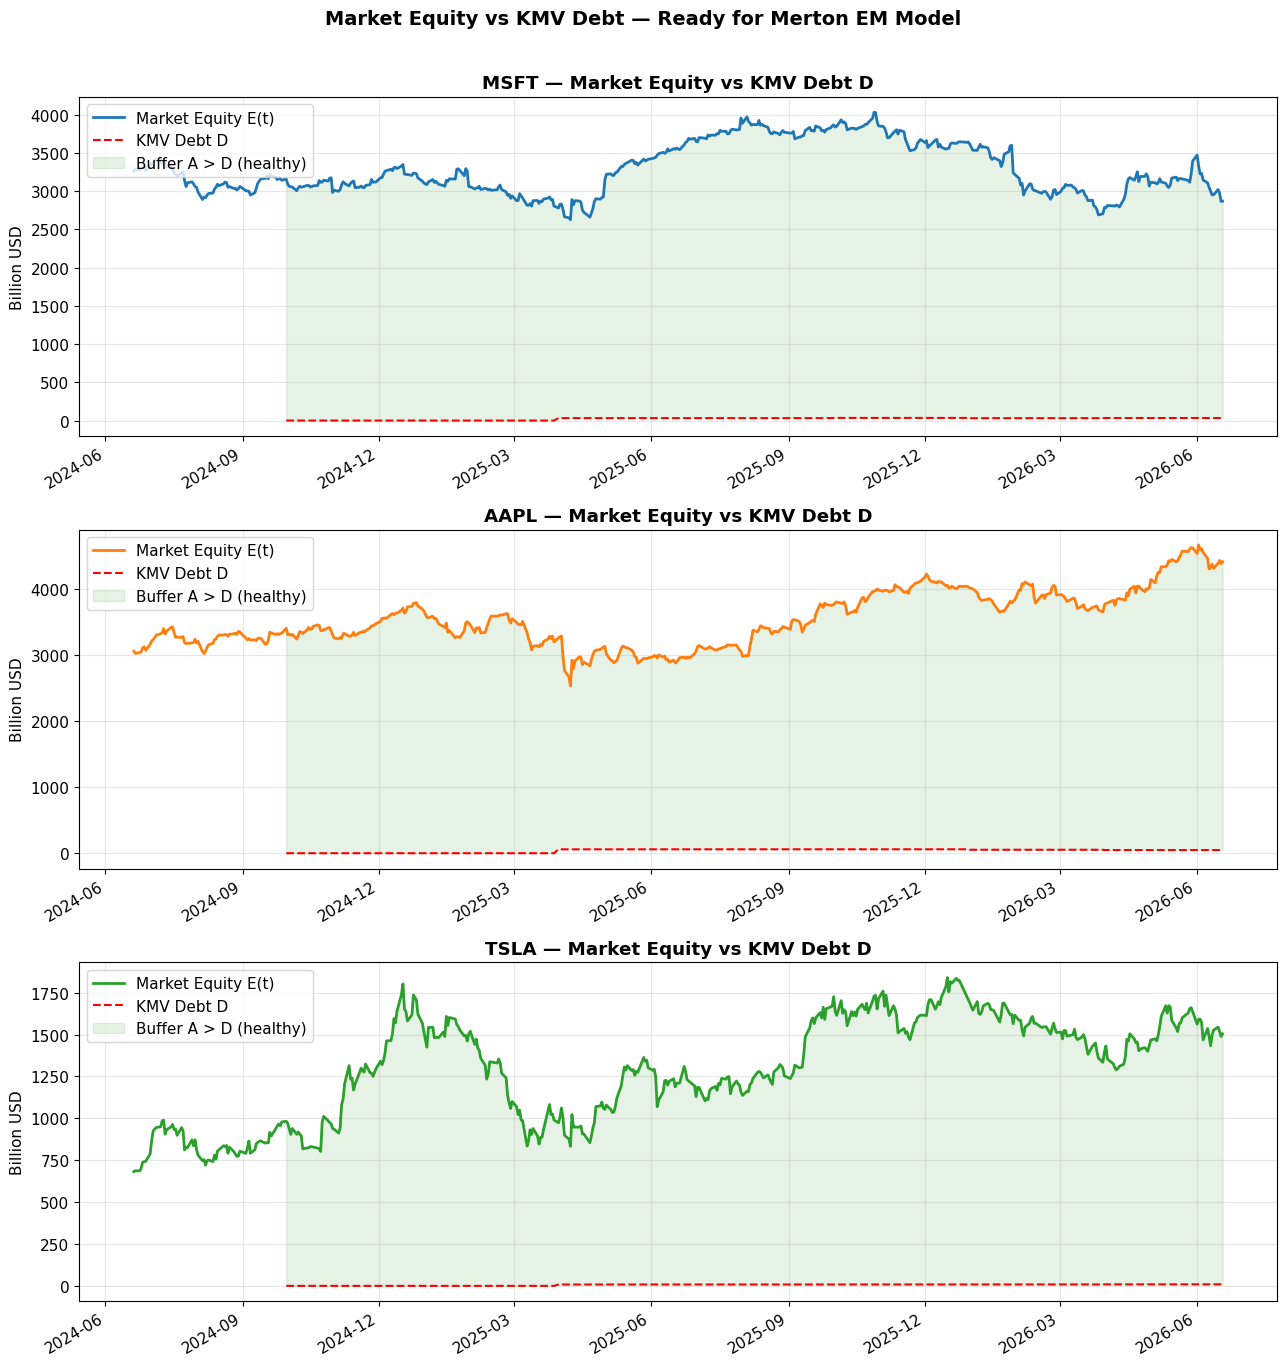

In [20]:
fig, axes = plt.subplots(len(master_data), 1,
                         figsize=(13, 4.5 * len(master_data)),
                         sharex=False)
if len(master_data) == 1:
    axes = [axes]

for ax, (t, master), color in zip(axes, master_data.items(), COLORS):
    # Convert to billions
    E = master['Equity']      / 1e9
    D = master['KMV_Debt_D']  / 1e9

    ax.plot(master.index, E, label='Market Equity E(t)', color=color,   lw=2)
    ax.plot(master.index, D, label='KMV Debt D',          color='red',   lw=1.5, linestyle='--')

    # Shade the gap (buffer above default point)
    ax.fill_between(master.index, D, E,
                    where=(E >= D), alpha=0.10, color='green',
                    label='Buffer A > D (healthy)')

    ax.set_title(f'{t} — Market Equity vs KMV Debt D', fontweight='bold')
    ax.set_ylabel('Billion USD')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Market Equity vs KMV Debt — Ready for Merton EM Model',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/equity_vs_debt_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 · Export to Excel (one workbook per company)

Each Excel file contains separate sheets:
- `PriceHistory` — daily OHLCV + dividends
- `MarketCap` — daily market cap
- `BalanceSheet` — quarterly debt data
- `RiskFreeRate` — daily Treasury yields
- `MasterDataset` — merged daily table ready for KMV

In [21]:
print('Exporting to Excel ...\n')

for t in TICKERS:
    if t not in master_data:
        continue

    path = f'{OUTPUT_DIR}/{t}/{t}_all_data.xlsx'

    with pd.ExcelWriter(path, engine='openpyxl') as writer:

        # Sheet 1: Price History
        price_data[t].to_excel(writer, sheet_name='PriceHistory')

        # Sheet 2: Market Cap
        if t in market_cap_data:
            market_cap_data[t].to_excel(writer, sheet_name='MarketCap')

        # Sheet 3: Balance Sheet
        balance_sheet_data[t].to_excel(writer, sheet_name='BalanceSheet', index=False)

        # Sheet 4: Risk Free Rate
        rf_df.to_excel(writer, sheet_name='RiskFreeRate')

        # Sheet 5: Master Dataset
        master_data[t].to_excel(writer, sheet_name='MasterDataset')

        # Sheet 6: Company Info
        pd.DataFrame([company_info[t]], index=[t]).T.to_excel(
            writer, sheet_name='CompanyInfo', header=False
        )

    print(f'  [{t}] ✅  Saved → {path}')

print('\nAll Excel files saved ✅')

Exporting to Excel ...

  [MSFT] ✅  Saved → ./data/MSFT/MSFT_all_data.xlsx
  [AAPL] ✅  Saved → ./data/AAPL/AAPL_all_data.xlsx
  [TSLA] ✅  Saved → ./data/TSLA/TSLA_all_data.xlsx

All Excel files saved ✅


---
## Step 9 · Data Quality Check

Before handing data to the KMV model, verify there are no critical issues.

In [22]:
print('\n' + '='*70)
print('  DATA QUALITY REPORT')
print('='*70)

for t, master in master_data.items():
    print(f'\n  ── {t} ──────────────────────────────────────────────────')

    total_rows   = len(master)
    has_debt     = master['KMV_Debt_D'].notna() & (master['KMV_Debt_D'] > 0)
    has_equity   = master['Equity'].notna()      & (master['Equity']    > 0)
    has_rf       = master['RiskFreeRate'].notna()

    print(f'  Total trading days        : {total_rows}')
    print(f'  Rows with valid Debt D    : {has_debt.sum()}')
    print(f'  Rows with valid Equity    : {has_equity.sum()}')
    print(f'  Rows with risk-free rate  : {has_rf.sum()}')
    print(f'  Rows ready for KMV        : {(has_debt & has_equity & has_rf).sum()}')

    # Sanity checks
    issues = []
    if (master['KMV_Debt_D'].fillna(0) < 0).any():
        issues.append('⚠️  Negative debt values detected')
    if (master['Equity'].fillna(0) < 0).any():
        issues.append('⚠️  Negative equity values detected')
    if master['Close'].isna().sum() > 5:
        issues.append(f'⚠️  {master["Close"].isna().sum()} missing price rows')

    if issues:
        for issue in issues:
            print(f'  {issue}')
    else:
        print('  ✅ No data quality issues found')

    # Key statistics
    print(f'\n  Key Statistics (latest available):')
    last = master.dropna(subset=['KMV_Debt_D', 'Equity']).iloc[-1]
    print(f'    Close Price   : ${last["Close"]:>12,.2f}')
    print(f'    Market Equity : ${last["Equity"]:>12,.0f}')
    print(f'    KMV Debt D    : ${last["KMV_Debt_D"]:>12,.0f}')
    print(f'    E / D ratio   : {last["E_over_D"]:>12.3f}')
    print(f'    Risk-Free r   : {last["RiskFreeRate"]:>12.4%}')
    print(f'    Tau           : {last["tau"]:>12.4f}')

print('\n' + '='*70)


  DATA QUALITY REPORT

  ── MSFT ──────────────────────────────────────────────────
  Total trading days        : 501
  Rows with valid Debt D    : 307
  Rows with valid Equity    : 501
  Rows with risk-free rate  : 501
  Rows ready for KMV        : 307
  ✅ No data quality issues found

  Key Statistics (latest available):
    Close Price   : $      379.40
    Market Equity : $2,868,861,482,685
    KMV Debt D    : $32,902,000,000
    E / D ratio   :       87.194
    Risk-Free r   :      3.6580%
    Tau           :       0.6840

  ── AAPL ──────────────────────────────────────────────────
  Total trading days        : 501
  Rows with valid Debt D    : 307
  Rows with valid Equity    : 501
  Rows with risk-free rate  : 501
  Rows ready for KMV        : 307
  ✅ No data quality issues found

  Key Statistics (latest available):
    Close Price   : $      298.01
    Market Equity : $4,407,234,914,920
    KMV Debt D    : $47,509,000,000
    E / D ratio   :       92.766
    Risk-Free r   :  

---
## Step 10 · Final File Summary

In [23]:
print('\n' + '='*70)
print('  OUTPUT FILE SUMMARY')
print('='*70)

for t in TICKERS:
    folder = f'{OUTPUT_DIR}/{t}'
    if not os.path.exists(folder):
        continue
    files = sorted(os.listdir(folder))
    print(f'\n  📁 {folder}/')
    for f in files:
        fpath = os.path.join(folder, f)
        size  = os.path.getsize(fpath)
        print(f'     📄 {f:<45} {size/1024:>7.1f} KB')

# Global files
print(f'\n  📁 {OUTPUT_DIR}/')
for f in ['risk_free_rates.csv',
          'price_history_chart.png',
          'normalised_performance.png',
          'market_cap_chart.png',
          'debt_structure_chart.png',
          'equity_vs_debt_chart.png',
          'risk_free_rate_chart.png']:
    fpath = os.path.join(OUTPUT_DIR, f)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath)
        print(f'     📄 {f:<45} {size/1024:>7.1f} KB')




  OUTPUT FILE SUMMARY

  📁 ./data/MSFT/
     📄 MSFT_all_data.xlsx                              145.7 KB
     📄 MSFT_balance_sheet.csv                            0.8 KB
     📄 MSFT_company_info.csv                             0.5 KB
     📄 MSFT_market_cap.csv                              44.5 KB
     📄 MSFT_master.csv                                 119.3 KB
     📄 MSFT_price_history.csv                           31.5 KB

  📁 ./data/AAPL/
     📄 AAPL_all_data.xlsx                              140.2 KB
     📄 AAPL_balance_sheet.csv                            0.8 KB
     📄 AAPL_company_info.csv                             0.4 KB
     📄 AAPL_market_cap.csv                              42.2 KB
     📄 AAPL_master.csv                                 116.9 KB
     📄 AAPL_price_history.csv                           31.4 KB

  📁 ./data/TSLA/
     📄 TSLA_all_data.xlsx                              126.1 KB
     📄 TSLA_balance_sheet.csv                            0.8 KB
     📄 TSLA_company_info.cs